In [4]:
import numpy as np
import matplotlib.pyplot as plt

In [6]:
class LinearNeuron:

  def __init__(self, n_inputs, learning_rate=0.1):
    self.w = - 1 + 2 * np.random.rand(n_inputs)
    self.b = - 1 + 2 * np.random.rand()
    self.eta = learning_rate

  def predict(self, X):
    Y_est = np.dot(self.w, X) + self.b
    return Y_est
  
  def batcher(self, X, Y, batch_size):
    p = X.shape[1]
    lo_index, hi_index = 0, batch_size
    ## Generator function batcher
    while(True):
        if(lo_index < p):
          yield(X[:, lo_index : hi_index], Y[:, lo_index : hi_index])
          lo_index, hi_index = (lo_index + batch_size), (hi_index + batch_size)
        else:
          return None

  def fit(self, X, Y, epochs = 50, batch_size = 20):
    p = X.shape[1]
    for _ in range(epochs):
        minibatch = self.batcher(X, Y, batch_size = batch_size)
        for mX, mY in minibatch: ## Use generated minibatch as an iterator
            Y_est = self.predict(mX)
            self.w += (self.eta / p) * np.dot((mY - Y_est), mX.T).ravel()
            self.b += (self.eta / p) * np.sum(mY - Y_est)

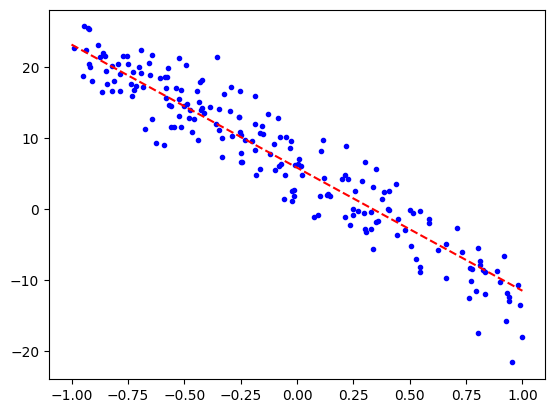

In [11]:
# Ejemplo
p = 200
# reshape(1,-1) ensures shape = (1, p)
x = -1 + 2 * np.random.rand(p).reshape(1,-1)
# y = -18x + 6 + ( 3 * gaussian noise range(0, 1))
y = -18 * x + 6 + 3.5 * np.random.randn(p)
plt.plot(x,y,'.b')

neuron = LinearNeuron(1, 0.1)
neuron.fit(x,y, epochs=100, batch_size=40)

# Dibujar línea
xn = np.array([[-1, 1]])
plt.plot(xn.ravel() ,neuron.predict(xn),'--r')
plt.show()